## Importing Libraries

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

## Loading Data

- User_ID : 사용자 아이디
- Product_ID : 상품 아이디
- Gender : 성별
- Age : 나이 (범주화된 상태 '0-17', '55+', '26-35', '46-50', '51-55', '36-45', '18-25')
- Occupation : 고객의 직업군 (?) (1 ~16)
- City_Category : 도시 (ABC)
- Stay_In_Current_City_Years : 지역 거주 기간 (0,1,2,3,4+)
- Marital_Status: 혼인 여부 (0,1)
- Product_Category: 상품 카테고리 (1~20)
- Purchase: 상품가

In [39]:
df = pd.read_csv('./data/walmart.csv')

## EDA

In [40]:
df.shape

(550068, 10)

In [41]:
# 중복된 User_ID가 있다. 
df.head()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
1,1000001,P00248942,F,0-17,10,A,2,0,1,15200
2,1000001,P00087842,F,0-17,10,A,2,0,12,1422
3,1000001,P00085442,F,0-17,10,A,2,0,12,1057
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969


In [42]:
df.tail()

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
550063,1006033,P00372445,M,51-55,13,B,1,1,20,368
550064,1006035,P00375436,F,26-35,1,C,3,0,20,371
550065,1006036,P00375436,F,26-35,15,B,4+,1,20,137
550066,1006038,P00375436,F,55+,1,C,2,0,20,365
550067,1006039,P00371644,F,46-50,0,B,4+,1,20,490


In [43]:
df.isnull().sum()

User_ID                       0
Product_ID                    0
Gender                        0
Age                           0
Occupation                    0
City_Category                 0
Stay_In_Current_City_Years    0
Marital_Status                0
Product_Category              0
Purchase                      0
dtype: int64

In [320]:
# 총 이용고객의 수 5891
df['User_ID'].nunique()

5891

In [325]:
df1 = df.drop_duplicates(subset='User_ID')
df1

,User_ID,Product_ID,Gender,Age,Occupation,City_Category,Stay_In_Current_City_Years,Marital_Status,Product_Category,Purchase
0,1000001,P00069042,F,0-17,10,A,2,0,3,8370
4,1000002,P00285442,M,55+,16,C,4+,0,8,7969
5,1000003,P00193542,M,26-35,15,A,3,0,1,15227
6,1000004,P00184942,M,46-50,7,B,2,1,1,19215
9,1000005,P00274942,M,26-35,20,A,1,1,8,7871
...,...,...,...,...,...,...,...,...,...,...
185450,1004588,P00260042,F,26-35,4,C,0,0,5,8707
187076,1004871,P00242742,M,18-25,12,C,2,0,1,15389
221494,1004113,P00351842,M,36-45,17,C,3,0,5,5183
229480,1005391,P00339342,M,26-35,7,A,0,0,1,15831


## Visualization

VIP 고객 도출 및 지역별 구매 고객 특징을 파악하여 마케팅 전략을 도출

###  1.  고객 파악
- 남성 고객이 4225명, 여성 고객이 1666명으로 남성 고객이 여성 고객보다 43.4% 더 많다.
- 26-35세 나이대 고객이 월마트를 가장 많이 이용하며 0-17세 나이대 고객이 가장 적게 이용한다. 
- C지역 > B 지역 > A 지역 순으로 월마트를 가장 많이 이용한다. 
- 1년 거주한 고객이 가장 많이 월마트를 이용한다. 1>2>3>4+>0 순이다. 
- 도시별로 공통적으로 높은 구매율은 1 > 5 > 8번 카테고리 순이었으며 9,17번은 구매율이 저조했다. <br>
  하지만 가장 많이 팔린 상품은 P00265242였으며 카테고리는 3번이었다. 

 

In [188]:
# 남성 고객이 여성 고객보다 43.4 % 더 많다. 
df_gender = df.groupby('User_ID').Gender.unique().reset_index()
df_gender = df_gender.Gender.value_counts()
df_gender

[M]    4225
[F]    1666
Name: Gender, dtype: int64

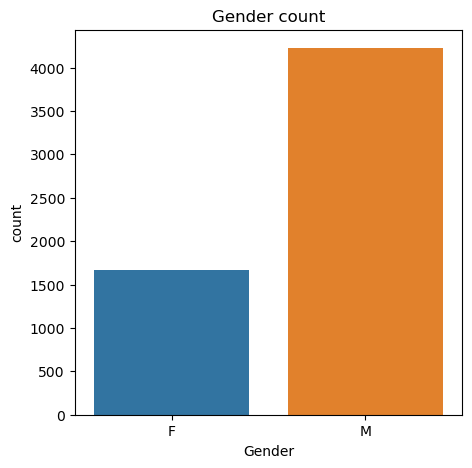

In [328]:
plt.figure(figsize=(5, 5))
sns.countplot(x='Gender',data=df1)
plt.xlabel('Gender')
plt.ylabel('count')
plt.title('Gender count')
plt.show()

Text(0.5, 1.0, 'Age Distribution')

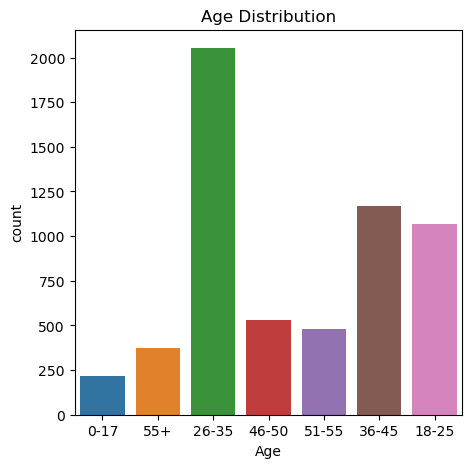

In [330]:
# 나이대별 구매 빈도수 
# 26-35세 나이대의 구매 빈도가 가장 높다. 
plt.figure(figsize=(5, 5))
sns.countplot(x='Age',data=df1)
plt.ylabel('count')
plt.title('Age Distribution')

In [331]:
# C 지역이 구매 횟수가 가장 많다. 
df1.City_Category.value_counts().sort_values(ascending=False)

C    3139
B    1707
A    1045
Name: City_Category, dtype: int64

Text(0.5, 1.0, 'City_Category')

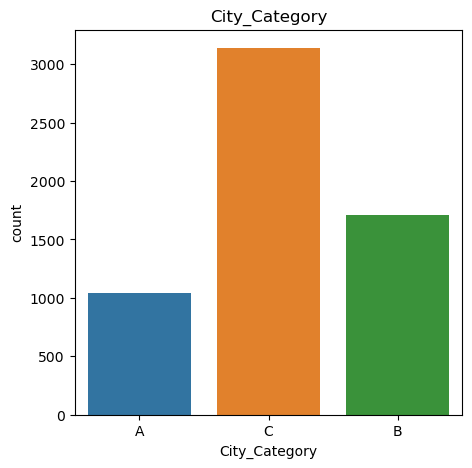

In [332]:
plt.figure(figsize=(5, 5))
sns.countplot(x='City_Category',data=df1)
plt.xlabel('City_Category')
plt.ylabel('count')
plt.title('City_Category')

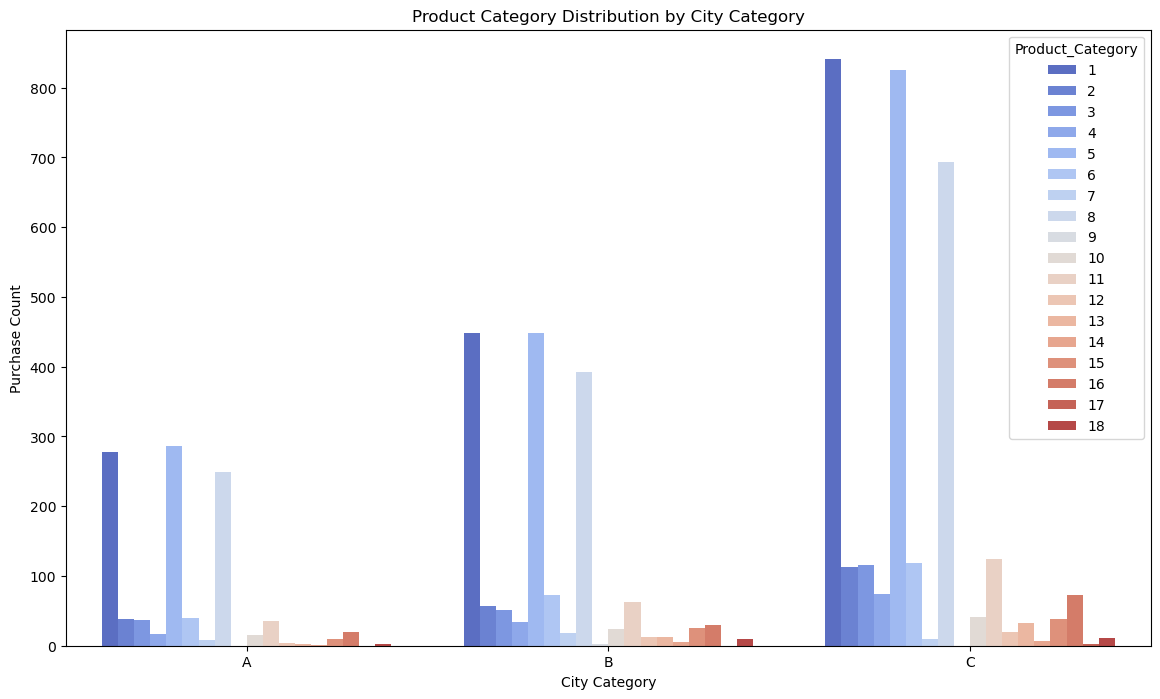

In [333]:
# 지역별 상품 카테고리 구매 분포 
# 1,5,8번 상품 품목이 공통적으로 가장 높은 구매율을 보인다. 
category_counts_by_city = df1.groupby(['City_Category', 'Product_Category']).size().reset_index(name='Count')

plt.figure(figsize=(14, 8))
sns.barplot(data=category_counts_by_city, x='City_Category', y='Count', hue='Product_Category', palette='coolwarm')
plt.title('Product Category Distribution by City Category')
plt.xlabel('City Category')
plt.ylabel('Purchase Count')
plt.show()


Text(0.5, 1.0, 'Stay_In_Current_City_Years')

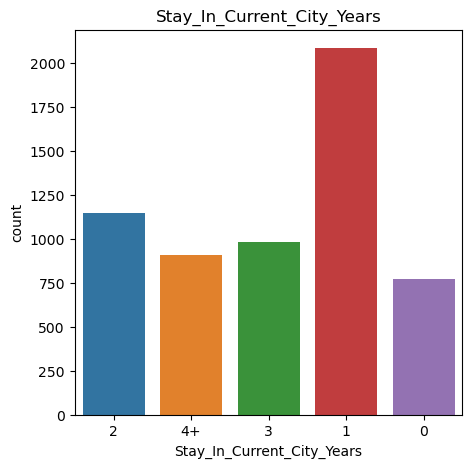

In [334]:
# 거주기간별 구매량
plt.figure(figsize=(5, 5))
sns.countplot(x='Stay_In_Current_City_Years',data=df1)
plt.xlabel('Stay_In_Current_City_Years')
plt.ylabel('count')
plt.title('Stay_In_Current_City_Years')

In [336]:
# 1번 카테고리 항목이 가장 구매율이 많다. 
top10_products['Product_Category'] = df['Product_Category']
top10_products

,Product_ID,Count,Product_Category
0,P00265242,1880,3
1,P00025442,1615,1
2,P00110742,1612,12
3,P00112142,1562,12
4,P00057642,1470,8
5,P00184942,1440,1
6,P00046742,1438,1
7,P00058042,1422,1
8,P00059442,1406,1
9,P00145042,1406,8


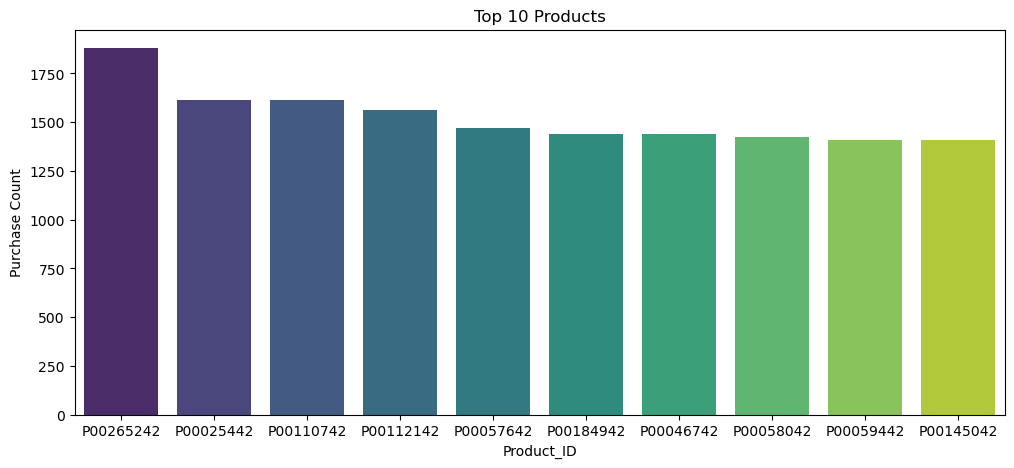

In [250]:
top10_products= df.Product_ID.value_counts().reset_index().head(10)
top10_products= top10_products.rename(columns={'index': 'Product_ID', 'Product_ID': 'Count'})

plt.figure(figsize=(12, 5))
sns.barplot(data=top10_products, x='Product_ID', y='Count', palette='viridis')
plt.title('Top 10 Products')
plt.xlabel('Product_ID')
plt.ylabel('Purchase Count')
plt.show()

### 2.  VIP 고객은 누구인가?

- VIP 정의: 총 구매액이 많은 상위 10% 고객 <br>
윌마트를 이용하는 가장 많은 고객은 C지역이나 상위 10%의 고객은 A 지역 출신이 많았다. <br>
미혼 357명 기혼 232명으로 미혼 고객의 수가 더 많다. 




In [349]:
#총 구매 횟수가 가장 높은 고객 10명 
customer_purchase_counts = df.groupby('User_ID').agg({'Purchase':'count' , 'Gender' :'first','Age':'first','City_Category':'first','Marital_Status':'first'}).reset_index()
customer_purchase_counts = customer_purchase_counts.sort_values(by='Purchase', ascending= False)
customer_purchase_counts.head(10)

,User_ID,Purchase,Gender,Age,City_Category,Marital_Status
1634,1001680,1026,M,26-35,A,1
4166,1004277,979,M,36-45,A,0
1885,1001941,898,M,36-45,A,0
1142,1001181,862,M,36-45,A,1
863,1000889,823,M,46-50,A,0
3520,1003618,767,M,55+,A,1
1111,1001150,752,F,26-35,A,0
981,1001015,740,M,36-45,A,1
5647,1005795,729,M,26-35,A,1
5683,1005831,727,M,26-35,A,1


In [350]:
# 구매 횟수가 높은 상위 10% 고객 
top_10_percent_index = int(len(customer_purchase_counts) * 0.1)
top_10_percent_customers_pc = customer_purchase_counts.iloc[:top_10_percent_index]
top_10_percent_customers_pc

,User_ID,Purchase,Gender,Age,City_Category,Marital_Status
1634,1001680,1026,M,26-35,A,1
4166,1004277,979,M,36-45,A,0
1885,1001941,898,M,36-45,A,0
1142,1001181,862,M,36-45,A,1
863,1000889,823,M,46-50,A,0
...,...,...,...,...,...,...
1727,1001776,227,M,26-35,B,1
1085,1001124,227,M,26-35,B,1
25,1000026,226,M,26-35,B,1
4775,1004897,225,M,36-45,B,0


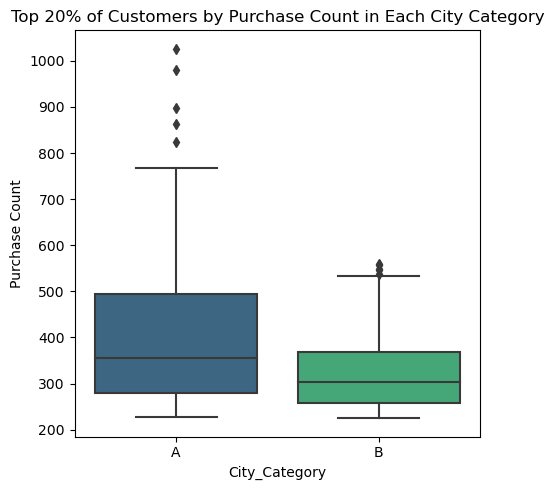

In [351]:
# 구매 횟수가 높은 상위 10% 고객 시각화 
plt.figure(figsize=(5, 5))
sns.boxplot(data=top_10_percent_customers_pc, x='City_Category', y='Purchase', palette='viridis')
plt.title('Top 20% of Customers by Purchase Count in Each City Category')
plt.ylabel('Purchase Count')
plt.xlabel('City_Category')

plt.tight_layout()
plt.show()

In [353]:
#총 구매 금액이 가장 높은 고객 
customer_purchase_buys = df.groupby('User_ID').agg({'Purchase':'sum' , 'Gender' :'first','Age':'first','City_Category':'first','Marital_Status':'first'}).reset_index()
customer_purchase_buys= customer_purchase_buys.sort_values(by='Purchase', ascending=False)


In [354]:
# 구매 금액이 높은 상위 10% 고객 
top_10_percent_index = int(len(customer_purchase_buys) * 0.1)
top_10_percent_customers_pb = customer_purchase_buys.iloc[:top_10_percent_index]
top_10_percent_customers_pb

,User_ID,Purchase,Gender,Age,City_Category,Marital_Status
4166,1004277,10536909,M,36-45,A,0
1634,1001680,8699596,M,26-35,A,1
2831,1002909,7577756,M,26-35,A,0
1885,1001941,6817493,M,36-45,A,0
416,1000424,6573609,M,26-35,A,0
...,...,...,...,...,...,...
3615,1003715,2075961,M,18-25,B,0
5384,1005523,2075512,M,36-45,B,1
2177,1002237,2075333,F,36-45,B,0
3526,1003624,2073593,M,26-35,B,1


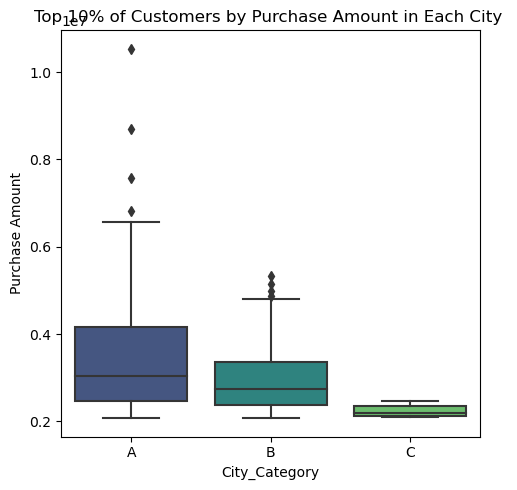

In [355]:
# 상위 10% 고객의 총 구매 금액 시각화 

plt.figure(figsize=(5, 5))
sns.boxplot(data=top_10_percent_customers_pb, x='City_Category', y='Purchase', palette='viridis')
plt.title('Top 10% of Customers by Purchase Amount in Each City ')
plt.ylabel('Purchase Amount')
plt.xlabel('City_Category')

plt.tight_layout()
plt.show()

In [348]:
# 상위 10% 고객은 미혼이 더 많다. 
top_10_percent_customers_pb.Marital_Status.value_counts()

0    357
1    232
Name: Marital_Status, dtype: int64